FUENTE:
[ROMPER CÓDIGO ENIGMA](https://medium.com/data-science/breaking-the-enigma-code-in-python-with-mcmc-marvel-themed-9ceb358dd8ae)

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
import os
#os.chdir('C:/Users/Jack Wills/Documents/Portfolio/Projects/MCMC - Enigma Thanos')
from google.colab import files

In [ ]:
files.upload()

In [3]:
text = open('marvel_data.txt', encoding="utf8").read().lower()

In [4]:
len(text)

28213380

In [5]:
known_chars = 'abcdefghijklmnopqrstuvwxyz0123456789 ,.?!:;'

In [ ]:
def create_empty_dict(known_chars):
    # ---------------------------------------------------------
    # Crea un diccionario vacío con estructura de matriz cuadrada
    # ---------------------------------------------------------
    empty_dict = {}
    for i in known_chars:               # Por cada carácter posible (fila)
        for j in known_chars:           # Por cada carácter posible (columna)
            empty_dict.setdefault(i, {})[j] = 0
            # setdefault(i,{}) asegura que exista una subclave para 'i'
            # Luego crea un diccionario interno con todas las combinaciones posibles
            # Ejemplo: {'a': {'a':0,'b':0,'c':0}, 'b': {'a':0,'b':0,'c':0}, ...}
    return empty_dict                   # Devuelve una matriz de ceros

# ---------------------------------------------------------
# Construye una matriz de frecuencias de pares consecutivos
# ---------------------------------------------------------
def create_count_dict(text, known_chars):
    count_dict = create_empty_dict(known_chars)  # Inicializa la matriz en 0

    for i in range(len(text) - 1):               # Recorre el texto carácter por carácter
        char_a = text[i]                         # Carácter actual
        char_b = text[i + 1]                     # Carácter siguiente

        # Si ambos caracteres son conocidos, se cuenta la transición
        if char_a in known_chars and char_b in known_chars:
            count_dict[char_a][char_b] += 1      # Incrementa el contador de esa transición

    return count_dict                            # Devuelve la matriz de conteos

# ---------------------------------------------------------
# Convierte la matriz de frecuencias en una matriz de probabilidades (logarítmicas)
# ---------------------------------------------------------
def create_perc_dict(count_dict, known_chars):
    perc_dict = create_empty_dict(known_chars)   # Estructura base para guardar proporciones

    for i in known_chars:                        # Para cada carácter de origen
        total_count = sum(count_dict[i].values())# Suma total de transiciones desde 'i'

        for j in known_chars:                    # Para cada carácter destino
            # Calcula la probabilidad de transición i→j con suavizado
            letter_perc = (count_dict[i][j] + 1) / total_count
            # Se suma +1 (Laplace smoothing) para evitar log(0)
            perc_dict[i][j] = np.log(letter_perc)
            # Se guarda el logaritmo natural de la probabilidad
            # (útil para sumas logarítmicas en modelos probabilísticos)
    return perc_dict


In [7]:
count_dict = create_count_dict(text, known_chars)
perc_dict = create_perc_dict(count_dict, known_chars)

In [8]:
count_dict

{'a': {'a': 1454,
  'b': 39363,
  'c': 89594,
  'd': 76129,
  'e': 2336,
  'f': 26663,
  'g': 49485,
  'h': 3873,
  'i': 61309,
  'j': 1354,
  'k': 27137,
  'l': 161602,
  'm': 71395,
  'n': 403327,
  'o': 1198,
  'p': 50067,
  'q': 417,
  'r': 182546,
  's': 206772,
  't': 239287,
  'u': 23299,
  'v': 38347,
  'w': 16054,
  'x': 4061,
  'y': 22870,
  'z': 6066,
  '0': 0,
  '1': 1,
  '2': 1,
  '3': 0,
  '4': 0,
  '5': 0,
  '6': 0,
  '7': 0,
  '8': 0,
  '9': 0,
  ' ': 147267,
  ',': 7523,
  '.': 8117,
  '?': 0,
  '!': 6,
  ':': 165,
  ';': 103},
 'b': {'a': 41943,
  'b': 4195,
  'c': 372,
  'd': 1210,
  'e': 92571,
  'f': 12,
  'g': 283,
  'h': 105,
  'i': 23269,
  'j': 1381,
  'k': 10,
  'l': 41071,
  'm': 429,
  'n': 141,
  'o': 41469,
  'p': 8,
  'q': 0,
  'r': 27247,
  's': 6033,
  't': 1243,
  'u': 34603,
  'v': 172,
  'w': 200,
  'x': 0,
  'y': 49666,
  'z': 6,
  '0': 0,
  '1': 14,
  '2': 0,
  '3': 0,
  '4': 0,
  '5': 0,
  '6': 0,
  '7': 0,
  '8': 0,
  '9': 0,
  ' ': 5064,
  ',': 

In [9]:
perc_dict

{'a': {'a': np.float64(-7.210370653396806),
  'b': np.float64(-3.9125248609835226),
  'c': np.float64(-3.0900770391678827),
  'd': np.float64(-3.2529341487021406),
  'e': np.float64(-6.73650849846354),
  'f': np.float64(-4.302062213014823),
  'g': np.float64(-3.683686752731907),
  'h': np.float64(-6.231088989035458),
  'i': np.float64(-3.469433592245665),
  'j': np.float64(-7.281575099688597),
  'k': np.float64(-4.2844415942965),
  'l': np.float64(-2.5002338437491467),
  'm': np.float64(-3.3171347086530005),
  'n': np.float64(-1.585626427325507),
  'o': np.float64(-7.4038886779748845),
  'p': np.float64(-3.6719944725544846),
  'q': np.float64(-8.457650400477643),
  'r': np.float64(-2.378368879907392),
  's': np.float64(-2.2537549808382407),
  't': np.float64(-2.1077087066232245),
  'u': np.float64(-4.436923193448607),
  'v': np.float64(-3.9386741788055115),
  'w': np.float64(-4.809356226478784),
  'x': np.float64(-6.183701090862069),
  'y': np.float64(-4.45550682153704),
  'z': np.floa

In [ ]:
import random

# ---------------------------------------------------------
# 1️⃣ Crea un alfabeto cifrado aleatorio
# ---------------------------------------------------------
def create_rand_crypt(known_chars):
    list_chars = list(known_chars)   # Convierte la cadena de caracteres conocidos en lista (para poder mezclar)
    random.shuffle(list_chars)       # Desordena la lista al azar
    rand_chars = ''.join(list_chars) # Une los caracteres desordenados en una nueva cadena
    return rand_chars                # Devuelve el "alfabeto cifrado" (ejemplo: 'abc' → 'bca')

# ---------------------------------------------------------
# 2️⃣ Genera el diccionario de sustitución (clave de cifrado)
# ---------------------------------------------------------
def str_to_key(known_chars, chars):
    crypt_dict = {}
    for i in range(len(known_chars)):
        crypt_dict[known_chars[i]] = chars[i]
        # Asocia cada carácter original con su correspondiente cifrado
        # Ejemplo: {'a':'x', 'b':'t', 'c':'p'}
    return crypt_dict                # Devuelve la clave como diccionario

# ---------------------------------------------------------
# 3️⃣ Aplica un diccionario de cifrado o descifrado a un texto
# ---------------------------------------------------------
def apply_dict(text, key_dict):
    text_list = list(text)           # Convierte el texto en lista (para modificarlo carácter por carácter)
    for i in range(len(text_list)):
        new_char = key_dict[text_list[i]]  # Sustituye cada carácter según el diccionario
        text_list[i] = new_char
    new_text = ''.join(text_list)    # Reconstruye el texto cifrado (o descifrado)
    return new_text                  # Devuelve el resultado final

# ---------------------------------------------------------
# 4️⃣ Invierte el diccionario (para descifrar)
# ---------------------------------------------------------
def invert_dict(key_dict):
    inverted_dict = {v: k for k, v in key_dict.items()}
    # Invierte las claves y valores. Ejemplo:
    # {'a':'x', 'b':'t', 'c':'p'} → {'x':'a', 't':'b', 'p':'c'}
    return inverted_dict


In [13]:
text = "My children, the time has come to execute my great plan and fulfil my destiny. \
The plan, as you know, is to use the cosmic entities known as the infinity stones to wipe half of the universe out of existence so that the other half may thrive. \
Our greatest challenge has been finding the stones in this vast universe, but now they are within our grasp. \
The space stone, knows also as the Tesseract, resides on Asgard. After Lokis failure on Earth, Thor has taken it and put it in Odins vault. \
The power stone is on Morag. I have ordered Ronan the Accuser to retrieve it for me, in return I shall destroy Xandar. \
The mind stone is on Earth, I put it in the staff I gave to Loki, but now I have heard that it is powering a cyborg known as The Vision. \
The reality stone is on the celestial head known as Knowhere. It is with Taneleer Tivan in his pathetic collection, gifted to him by the Asgardians after the Dark Elves failure in acquiring for themselves. \
The time stone is also on Earth, with a group of sorcerers, currently guarded by their leader, the Ancient One. \
The last stone, the soul stone, has yet to be found, but I have put my favourite daughter, Gamora, on to its trail, and she has not disappointed me yet. \
Once a stone is collected I will be able to harness its power using a gauntlet I have ordered the dwarves on Nidavellir. \
The time for cosmic order is near, and when I collect all the stones I will hold universe in my hands. \
Hugs and kisses,  \
Thanos".lower()

crypt_keys = create_rand_crypt(known_chars)
crypt_dict = str_to_key(known_chars, crypt_keys)
crypt_text = apply_dict(text, crypt_dict)

In [14]:
crypt_text

't3ulfn6h8yc4ukfyukntyufd?ul!tyuk!uy7ylikyut3ua8ydku06dcudchumi6mn6ut3uhy?knc3gukfyu06dc4ud?u3!iuvc!94un?uk!ui?yukfyul!?tnluycknkny?uvc!9cud?ukfyuncmncnk3u?k!cy?uk!u9n0yufd6mu!mukfyuicney8?yu!iku!muy7n?kyclyu?!ukfdkukfyu!kfy8ufd6mutd3ukf8neygu!i8ua8ydky?kulfd66ycayufd?u1yycumnchncaukfyu?k!cy?uncukfn?ued?kuicney8?y4u1ikuc!9ukfy3ud8yu9nkfncu!i8ua8d?0gukfyu?0dlyu?k!cy4uvc!9?ud6?!ud?ukfyuky??y8dlk4u8y?nhy?u!cud?ad8hgudmky8u6!vn?umdn6i8yu!cuyd8kf4ukf!8ufd?ukdvycunkudchu0ikunkuncu!hnc?uedi6kgukfyu0!9y8u?k!cyun?u!cut!8dagunufdeyu!8hy8yhu8!cdcukfyudlli?y8uk!u8yk8nyeyunkum!8uty4uncu8yki8cunu?fd66uhy?k8!3u7dchd8gukfyutnchu?k!cyun?u!cuyd8kf4unu0ikunkuncukfyu?kdmmunuadeyuk!u6!vn4u1ikuc!9unufdeyufyd8hukfdkunkun?u0!9y8ncaudul31!8auvc!9cud?ukfyuen?n!cgukfyu8yd6nk3u?k!cyun?u!cukfyuly6y?knd6ufydhuvc!9cud?uvc!9fy8ygunkun?u9nkfukdcy6yy8uknedcuncufn?u0dkfyknlul!66ylkn!c4uanmkyhuk!ufntu13ukfyud?ad8hndc?udmky8ukfyuhd8vuy6ey?umdn6i8yuncudl,in8ncaum!8ukfyt?y6ey?gukfyukntyu?k!cyun?ud6?!u!cuyd8kf4u9nkfudua8!i0u

In [ ]:
import random
import math
import numpy as np

# ---------------------------------------------------------
# 1️⃣ Evalúa la "verosimilitud" (likelihood) de un texto descifrado
# ---------------------------------------------------------
def score_likelihood(decrypted_text, perc_dict):
    total_likelihood = 0
    for i in range(len(decrypted_text) - 1):
        # Para cada par consecutivo de letras
        pair_likelihood = perc_dict[decrypted_text[i]][decrypted_text[i+1]]
        # Suma el log-probabilidad de esa transición (precalculada en perc_dict)
        total_likelihood += pair_likelihood
    return total_likelihood
    # Devuelve el log-likelihood total del texto: cuanto mayor, más probable según el idioma

# ---------------------------------------------------------
# 2️⃣ Crea una nueva "propuesta" de clave cambiando dos letras al azar
# ---------------------------------------------------------
def shuffle_pair(current_dict):
    key_list = list(current_dict.keys())        # Lista de letras originales
    a, b = random.sample(key_list, 2)           # Elige dos letras distintas al azar
    proposed_dict = current_dict.copy()         # Copia la clave actual
    proposed_dict[a], proposed_dict[b] = proposed_dict[b], proposed_dict[a]
    # Intercambia sus asignaciones (por ejemplo, 'a'→'x', 'b'→'q' pasa a 'a'→'q', 'b'→'x')
    return proposed_dict                        # Devuelve la clave propuesta

# ---------------------------------------------------------
# 3️⃣ Evalúa si aceptar la clave propuesta o no
# ---------------------------------------------------------
def eval_proposal(proposed_score, current_score):
    diff = proposed_score - current_score       # Diferencia de verosimilitud
    diff = min(1, diff)                         # Limita la diferencia máxima a 1
    diff = max(-1000, diff)                     # Limita la mínima a -1000 (para evitar overflow)
    ratio = math.exp(diff)                      # Calcula el ratio de aceptación (regla de Metropolis-Hastings)
    # Si el nuevo puntaje es mejor → aceptar
    # Si no, aceptar con una pequeña probabilidad (para evitar quedar atascado en óptimos locales)
    if ratio >= 1 or ratio > np.random.uniform(0,1):
        return True
    else:
        return False

# ---------------------------------------------------------
# 4️⃣ Bucle principal del descifrado con MCMC
# ---------------------------------------------------------
def decrypt_MCMC(cyphered_text, perc_dict, iters, known_chars, verbose = False):
    best_score = []     # Guarda los puntajes cada cierto número de iteraciones
    best_text = []      # Guarda los textos descifrados correspondientes

    # Step 1 - Crear una clave aleatoria inicial
    current_key = create_rand_crypt(known_chars)     # Crea un alfabeto aleatorio
    current_dict = str_to_key(known_chars, current_key)
    # ⚠️ OJO: en tu código original dice 'crypt_keys', pero debe ser 'current_key'

    # Step 2 - Descifrar el texto con esa clave inicial
    current_decrypted = apply_dict(cyphered_text, current_dict)

    # Step 3 - Evaluar su verosimilitud (qué tan "idiomático" parece)
    current_score = score_likelihood(current_decrypted, perc_dict)

    # ---------------------------------------------------------
    # Iteramos para mejorar la clave
    # ---------------------------------------------------------
    for i in range(iters):
        # Step 4 - Crear una nueva propuesta de clave
        proposed_dict = shuffle_pair(current_dict)

        # Step 5 - Descifrar nuevamente con la clave propuesta
        proposed_decrypted = apply_dict(cyphered_text, proposed_dict)

        # Step 6 - Calcular la nueva verosimilitud
        proposed_score = score_likelihood(proposed_decrypted, perc_dict)

        # Step 7 - Decidir si se acepta la propuesta
        if eval_proposal(proposed_score, current_score):
            current_dict = proposed_dict
            current_score = proposed_score
            current_decrypted = proposed_decrypted

        # Cada 500 iteraciones guardamos progreso
        if i % 500 == 0:
            best_score.append(current_score)
            best_text.append(current_decrypted)

        # Si verbose está activo, mostramos progreso cada 1000 iteraciones
        if verbose and i % 1000 == 0:
            print("Iteration:", i,
                  "| Score:", round(current_score, 2),
                  "| Text:", current_decrypted[0:70])

    # Devuelve la mejor clave encontrada y la evolución de puntajes/textos
    return current_dict, best_score, best_text


In [19]:
print("Log-likelihood of 'hello': " + str(score_likelihood('hello', perc_dict)))
print("Log-likelihood of 'z9kk3': " + str(score_likelihood('z9kk3', perc_dict)))


Log-likelihood of 'hello': -8.588655609033886
Log-likelihood of 'z9kk3': -32.581453007255924


In [22]:
iters = 25000
current_dict, best_score, best_text = decrypt_MCMC(crypt_text, perc_dict, iters, known_chars, verbose = True)

Iteration: 0. Score: -9458.54163875514. Message: k2i6mcrfw3l.ivm3ivck3imhji6ok3ivoi3b36nv3ik2idw3hvi:rhlihlfitnrtcrik2i
Iteration: 1000. Score: -4257.061202835183. Message: pk dhitgrely che cipe han dope co exeduce pk breac ftal alg sutsit pk 
Iteration: 2000. Score: -3980.996333257034. Message: gy thilkres, che cige han toge co exetuce gy dreac blas ask fulfil gy 
Iteration: 3000. Score: -3606.970441793116. Message: dy chilmren, the tide has code to execute dy great jlan anm fulfil dy 
Iteration: 4000. Score: -3594.783162098792. Message: dy chilmren, the tide has code to execute dy great blan anm fulfil dy 
Iteration: 5000. Score: -3504.788866499. Message: my children. the time has come to execute my great klan and fulfil my 
Iteration: 6000. Score: -3465.595151905035. Message: my children. the time has come to execute my great blan and fulfil my 
Iteration: 7000. Score: -3449.4071384112485. Message: my children. the time has come to execute my great plan and fulfil my 
Iteration: 800

In [23]:
best_text[-1]

'my children. the time has come to execute my great plan and fulfil my destiny, the plan. as you know. is to use the cosmic entities known as the infinity stones to wipe half of the universe out of existence so that the other half may thrive, our greatest challenge has been finding the stones in this vast universe. but now they are within our grasp, the space stone. knows also as the tesseract. resides on asgard, after lokis failure on earth. thor has taken it and put it in odins vault, the power stone is on morag, i have ordered ronan the accuser to retrieve it for me. in return i shall destroy xandar, the mind stone is on earth. i put it in the staff i gave to loki. but now i have heard that it is powering a cyborg known as the vision, the reality stone is on the celestial head known as knowhere, it is with taneleer tivan in his pathetic collection. gifted to him by the asgardians after the dark elves failure in acquiring for themselves, the time stone is also on earth. with a group 

In [24]:
# Repeat the MCMC X times, recording the final log-likelihood for each & the final decryption key
def cross_validation(attempts, cyphered_text, perc_dict, iters, known_chars):
    all_scores = []
    all_samples = []
    for i in range(attempts):
        decrpyt_dict, scores, samples = decrypt_MCMC(cyphered_text, perc_dict, iters, known_chars)
        all_scores.append(scores)
        all_samples.append(samples[-1])
    return all_samples, all_scores

In [25]:
cvs = 100
all_samples, all_scores = cross_validation(cvs, crypt_text, perc_dict, iters, known_chars)

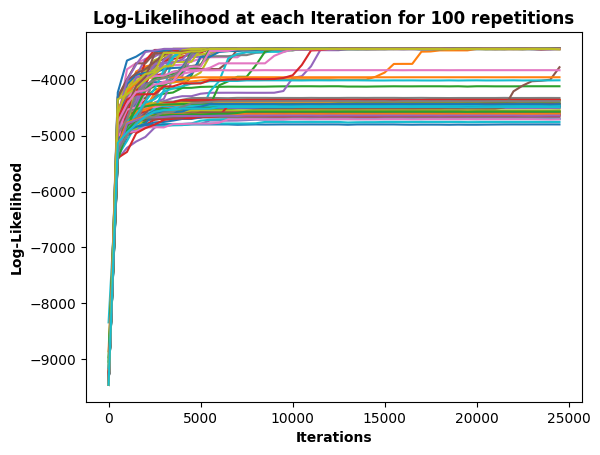

In [26]:
range_iters = list(range(0, iters, 500))
plt.xlabel("Iterations", fontweight = 'bold')
plt.ylabel("Log-Likelihood", fontweight = 'bold')
plt.title("Log-Likelihood at each Iteration for 100 repetitions", fontweight = 'bold')
for i in range(len(all_scores)):
    plt.plot(range_iters, all_scores[i])
plt.show()

In [27]:
def record_first_final(all_scores):
    first_scores = []
    final_scores = []
    final_samples = []
    for i in range(len(all_scores)):
        first_scores.append(all_scores[i][1])
        final_scores.append(all_scores[i][-1])
        final_samples.append(all_samples[i])
    return first_scores, final_scores, final_samples

In [28]:
first_scores, final_scores, final_samples = record_first_final(all_scores)

<ipython-input-29-d63c644dbe94>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(final_scores, kde = False, bins = 6, hist_kws=dict(edgecolor="k", linewidth=2))


(0.0, 100.0)

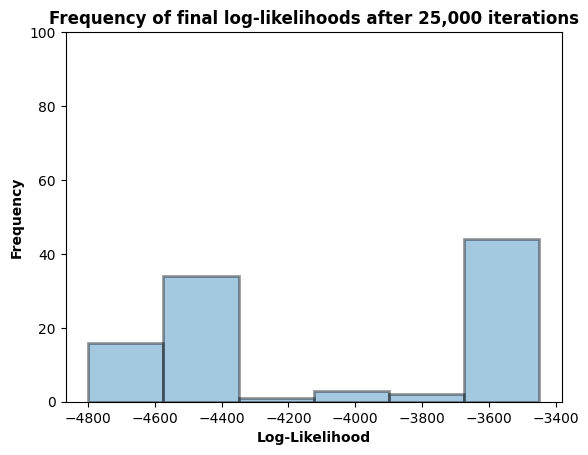

In [29]:
ax = sns.distplot(final_scores, kde = False, bins = 6, hist_kws=dict(edgecolor="k", linewidth=2))
ax.set_xlabel('Log-Likelihood', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
ax.set_title('Frequency of final log-likelihoods after 25,000 iterations', fontweight = 'bold')
ax.set_ylim(0, 100)

In [30]:
def print_success(final_scores, global_maxima):
    global_maxima -= 100
    success = sum(i > global_maxima for i in final_scores)
    failures = len(final_scores) - success
    succ_perc = str(round((success / len(final_scores))*100))
    print("Algorithm coverges successfully: ", str(success), " times")
    print("Algorithm coverges unsuccessfully: ", str(failures), " times")
    print("Algorithm has a " + succ_perc + "% success rate")
    return succ_perc

In [31]:
global_maxima = max(final_scores)
print_success(final_scores, global_maxima)

Algorithm coverges successfully:  44  times
Algorithm coverges unsuccessfully:  56  times
Algorithm has a 44% success rate


'44'

In [32]:
score_samples = zip(final_scores, final_samples)
sorted_score_samples = sorted(score_samples, key = lambda x: x[0], reverse = True)
example_sample = []
example_score = []
for i in range(int(len(sorted_score_samples)/10)):
    if len(example_score) == 0 or sorted_score_samples[i*10][0] < example_score[-1] - 150:
        example_sample.append(sorted_score_samples[i*10][1][0:100])
        example_score.append(sorted_score_samples[i*10][0])
example_sample.append(sorted_score_samples[-1][1][0:100])
example_score.append(sorted_score_samples[-1][0])

In [33]:
example_sample

['my children. the time has come to execute my great plan and fulfil my destiny, the plan. as you know',
 'ckidgelmt rhing inec igasidoc inoi x dun ickipt anizlariarmivulvelickim snerkwing izlarhiasikouibrof',
 'm.igoankl rwito itam iousigem itei j gpt im.ibl utiznuriurkicpncanim.ik star.hito iznurwiusi.epifrev',
 'kjemtacuordve tre akretisemnkre nerzrmy rekjepori ewcideiduelyclacekjeurs adjhe trewcidveisejnye.dng']

In [34]:
example_score

[np.float64(-3449.4071384112485),
 np.float64(-4360.73281884282),
 np.float64(-4569.761131998853),
 np.float64(-4799.885030470839)]